In [1]:
import numpy as np
import scipy.linalg as slin
import scipy.optimize as sopt
from scipy.special import expit as sigmoid
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import utils
from sklearn.model_selection import KFold
utils.set_random_seed(8)

In [2]:
def notears_linear(X, lambda1, loss_type, w_threshold, max_iter=100, h_tol=1e-8, rho_max=1e+16):
    """Solve min_W L(W; X) + lambda1 ‖W‖_1 s.t. h(W) = 0 using augmented Lagrangian.
    Args:
        X (np.ndarray): [n, d] sample matrix
        lambda1 (float): l1 penalty parameter
        loss_type (str): l2, logistic, poisson
        max_iter (int): max num of dual ascent steps
        h_tol (float): exit if |h(w_est)| <= htol
        rho_max (float): exit if rho >= rho_max
        w_threshold (float): drop edge if |weight| < threshold

    Returns:
        W_est (np.ndarray): [d, d] estimated DAG
    """
    def _loss(W):
        """Evaluate value and gradient of loss."""
        M = X @ W
        if loss_type == 'l2':
            R = X - M
            loss = 0.5 / X.shape[0] * (R ** 2).sum()
            G_loss = - 1.0 / X.shape[0] * X.T @ R
        elif loss_type == 'logistic':
            loss = 1.0 / X.shape[0] * (np.logaddexp(0, M) - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (sigmoid(M) - X)
        elif loss_type == 'poisson':
            S = np.exp(M)
            loss = 1.0 / X.shape[0] * (S - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (S - X)
        else:
            raise ValueError('unknown loss type')
        return loss, G_loss

    def _h(W):
        """Evaluate value and gradient of acyclicity constraint."""
        E = slin.expm(W * W)  # (Zheng et al. 2018)
        h = np.trace(E) - d
        #     # A different formulation, slightly faster at the cost of numerical stability
        #     M = np.eye(d) + W * W / d  # (Yu et al. 2019)
        #     E = np.linalg.matrix_power(M, d - 1)
        #     h = (E.T * M).sum() - d
        G_h = E.T * W * 2
        return h, G_h

    def _adj(w):
        """Convert doubled variables ([2 d^2] array) back to original variables ([d, d] matrix)."""
        return (w[:d * d] - w[d * d:]).reshape([d, d])

    def _func(w):
        """Evaluate value and gradient of augmented Lagrangian for doubled variables ([2 d^2] array)."""
        W = _adj(w)
        loss, G_loss = _loss(W)
        h, G_h = _h(W)
        obj = loss + 0.5 * rho * h * h + alpha * h + lambda1 * w.sum()
        G_smooth = G_loss + (rho * h + alpha) * G_h
        g_obj = np.concatenate((G_smooth + lambda1, - G_smooth + lambda1), axis=None)
        return obj, g_obj

    n, d = X.shape
    w_est, rho, alpha, h = np.zeros(2 * d * d), 1.0, 0.0, np.inf  # double w_est into (w_pos, w_neg)
    bnds = [(0, 0) if i == j else (0, None) for _ in range(2) for i in range(d) for j in range(d)]
    if loss_type == 'l2':
        X = X - np.mean(X, axis=0, keepdims=True)
    for _ in range(max_iter):
        w_new, h_new = None, None
        while rho < rho_max:
            sol = sopt.minimize(_func, w_est, method='L-BFGS-B', jac=True, bounds=bnds)
            w_new = sol.x
            h_new, _ = _h(_adj(w_new))
            if h_new > 0.25 * h:
                rho *= 10
            else:
                break
        w_est, h = w_new, h_new
        alpha += rho * h
        if h <= h_tol or rho >= rho_max:
            break
    W_est = _adj(w_est)
    W_est[np.abs(W_est) < w_threshold] = 0
    return W_est


In [3]:

def validate(nodes, edges):

    # Builds a random DAG with specified number of nodes and edges, and finds cutoff parameter using adjusted reconstruction error and CV.
    # Outputs are the metrics [SHD, FPR, TPR] for the cutoff at 0.3, the cross-validated cutoff and the (theoretically) optimal cutoff.

    B_true = utils.simulate_dag(nodes, edges, 'ER')
    W_true = utils.simulate_parameter(B_true)
    X = utils.simulate_linear_sem(W_true, nodes*10, 'gauss')

    # Evaluation
    
    # If you want to test the thresholds starting at 0.0 you need to remove the acyclicity constraint from the utils.py evaluation function!
    thresholds = np.arange(0.0, 0.35, 0.01)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=5)
    mse_values = []
    shd_values = []
    tpr_values = []
    fpr_values = []

    for threshold in thresholds:
            fold_mses = []
            for train_idx, test_idx in kf.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                W_est = notears_linear(X_train, lambda1=0.1, loss_type='l2', w_threshold=threshold)
                X_pred = X_test @ W_est
                nonzero = np.count_nonzero(W_est)/nodes   
                lambdo = 0.01
                mse = np.mean((X_test - X_pred) ** 2) + lambdo * nonzero
                fold_mses.append(mse)
            
            W_est_full = notears_linear(X, lambda1=0.1, loss_type='l2', w_threshold=threshold)
            acc = utils.count_accuracy(B_true, W_est_full != 0)
            shd_values.append(acc['shd'])
            tpr_values.append(acc['tpr'])
            fpr_values.append(acc['fpr'])
            avg_mse = np.mean(fold_mses)
            mse_values.append(avg_mse)

    # Find threshold with minimal MSE
    min_mse_idx = np.argmin(mse_values)
    best_threshold = thresholds[min_mse_idx]

    # Find threshold with minimal SHD
    min_shd = np.min(shd_values)
    min_shd_idx = np.argmin(shd_values)
    best_shd_threshold = thresholds[min_shd_idx]
    best_shd_tpr = tpr_values[min_shd_idx]
    best_shd_fpr = fpr_values[min_shd_idx]


    idx_03 = np.argmin(np.abs(thresholds - 0.3))
    shd_03 = shd_values[idx_03]
    tpr_03 = tpr_values[idx_03]
    fpr_03 = fpr_values[idx_03]

        
    shd_cv = shd_values[min_mse_idx]
    tpr_cv = tpr_values[min_mse_idx]
    fpr_cv = fpr_values[min_mse_idx]

    print(f"\nCross-Validated Threshold at {best_threshold:.4f} with SHD: {shd_cv} ")

    print(f"Best SHD at Threshold: {best_shd_threshold:.4f} with SHD  {min_shd}")

    print(f"SHD for the papers' Threshold (0.3): {shd_03}")

    matrix = np.round([[min_shd, best_shd_tpr, best_shd_fpr],[shd_03, tpr_03, fpr_03],[shd_cv, tpr_cv, fpr_cv]], 2)
    return matrix


In [4]:
nodes_10_edges_10 = validate(10, 10)
nodes_20_edges_20 = validate(20, 20)
nodes_30_edges_30 = validate(30, 30)
nodes_40_edges_40 = validate(40, 40)
nodes_50_edges_50 = validate(50, 50)




Cross-Validated Threshold at 0.2200 with SHD: 5 
Best SHD at Threshold: 0.1300 with SHD  5
SHD for the papers' Threshold (0.3): 5

Cross-Validated Threshold at 0.1300 with SHD: 8 
Best SHD at Threshold: 0.0600 with SHD  7
SHD for the papers' Threshold (0.3): 9

Cross-Validated Threshold at 0.1300 with SHD: 6 
Best SHD at Threshold: 0.0800 with SHD  6
SHD for the papers' Threshold (0.3): 11

Cross-Validated Threshold at 0.1000 with SHD: 5 
Best SHD at Threshold: 0.0900 with SHD  5
SHD for the papers' Threshold (0.3): 11

Cross-Validated Threshold at 0.0700 with SHD: 8 
Best SHD at Threshold: 0.0600 with SHD  7
SHD for the papers' Threshold (0.3): 19


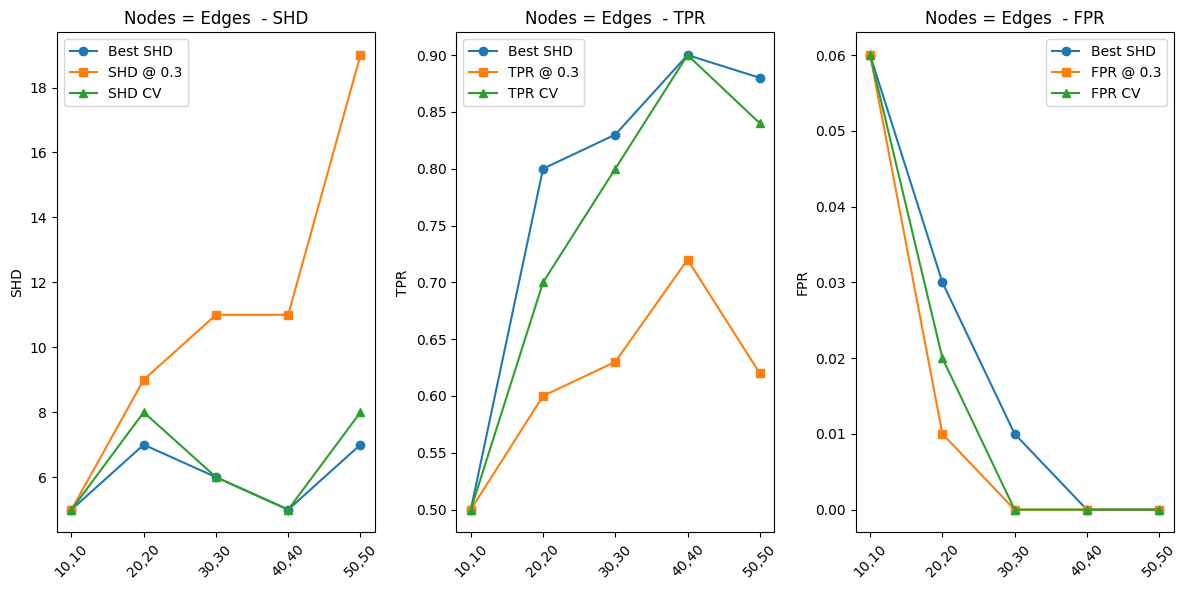

In [5]:
import matplotlib.pyplot as plt

# Prepare data for each block
# Block 1: nodes = edges
block1 = [
    ("10,10", nodes_10_edges_10),
    ("20,20", nodes_20_edges_20),
    ("30,30", nodes_30_edges_30),
    ("40,40", nodes_40_edges_40),
    ("50,50", nodes_50_edges_50),
]


def plot_block(block, title):
    labels = [label for label, _ in block]
    min_shd = [scores[0,0] for _, scores in block]
    shd_03 = [scores[1,0] for _, scores in block]
    shd_cv = [scores[2,0] for _, scores in block]
    tpr_min = [scores[0,1] for _, scores in block]
    tpr_03 = [scores[1,1] for _, scores in block]
    tpr_cv = [scores[2,1] for _, scores in block]
    fpr_min = [scores[0,2] for _, scores in block]
    fpr_03 = [scores[1,2] for _, scores in block]
    fpr_cv = [scores[2,2] for _, scores in block]

    x = range(len(labels))

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.plot(x, min_shd, 'o-', label='Best SHD')
    plt.plot(x, shd_03, 's-', label='SHD @ 0.3')
    plt.plot(x, shd_cv, '^-', label='SHD CV')
    plt.xticks(x, labels, rotation=45)
    plt.ylabel('SHD')
    plt.title(f'{title} - SHD')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(x, tpr_min, 'o-', label='Best SHD')
    plt.plot(x, tpr_03, 's-', label='TPR @ 0.3')
    plt.plot(x, tpr_cv, '^-', label='TPR CV')
    plt.xticks(x, labels, rotation=45)
    plt.ylabel('TPR')
    plt.title(f'{title} - TPR')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(x, fpr_min, 'o-', label='Best SHD')
    plt.plot(x, fpr_03, 's-', label='FPR @ 0.3')
    plt.plot(x, fpr_cv, '^-', label='FPR CV')
    plt.xticks(x, labels, rotation=45)
    plt.ylabel('FPR')
    plt.title(f'{title} - FPR')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_block(block1, "Nodes = Edges ")
